In [1]:
import os
import torch
import torch.nn as nn
import numpy as np
from tqdm.notebook import trange, tqdm
import h5py
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import glob
from torch.utils.data import TensorDataset, random_split, DataLoader
#from sklearn.metrics import f1_score, average_precision_score
#from flwr.app import MetricRecord
#!pip list

In [2]:
########## set device
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
##########
tqdm.write("Use device: {device:}\n".format(device=device))

Use device: cuda



## Data Analysis

In [7]:
df = pd.read_csv('data/code15-12l/exams.csv')
df2 = df.drop_duplicates(subset=["patient_id"])
len(df), len(df2)

(345779, 233770)

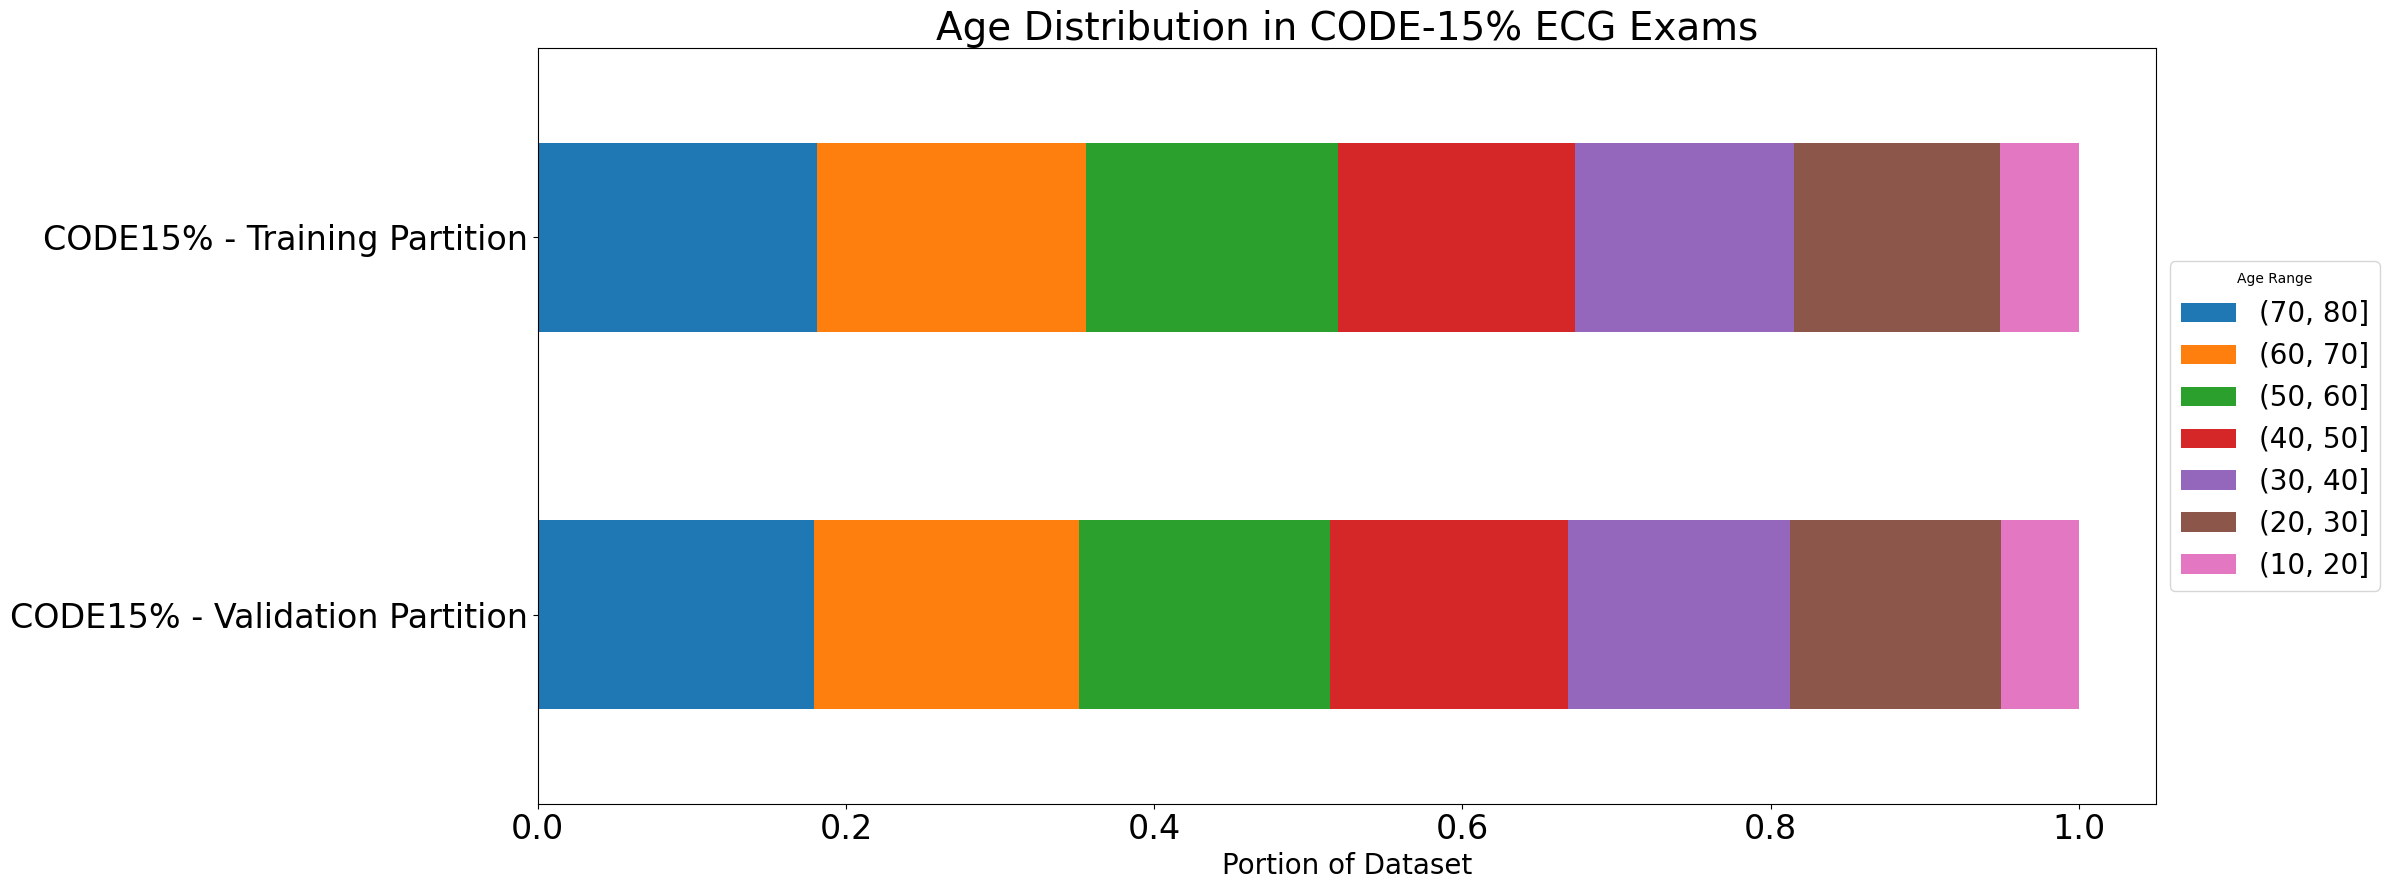

In [57]:
train = df[~df.trace_file.isin(["exams_part0.hdf5","exams_part1.hdf5","exams_part2.hdf5","exams_part3.hdf5"])].copy()
valid = df[df.trace_file.isin(["exams_part0.hdf5","exams_part1.hdf5","exams_part2.hdf5","exams_part3.hdf5"])].copy()

train["age_bins"] = pd.cut(train["age"], bins, labels)
valid["age_bins"] = pd.cut(valid["age"], bins, labels)

train_counts = train["age_bins"].value_counts(normalize=True).to_frame()
train_counts["validation"] = valid["age_bins"].value_counts(normalize=True)

train_counts.columns = ['CODE15% - Training Partition', 'CODE15% - Validation Partition']
ax = train_counts[sorted(['CODE15% - Training Partition', 'CODE15% - Validation Partition'], reverse=True)].T.plot.barh(stacked=True, figsize=(24, 9), fontsize=24)
plt.title("Age Distribution in CODE-15% ECG Exams", fontsize=28)
plt.xlabel("Portion of Dataset", fontsize=20)
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), title="Age Range", fontsize=20)

# annotations:
for c in ax.containers:   
    # format the number of decimal places and replace 0 with an empty string
    labels = [f'{w*100:.4f}%' if (w := v.get_width()) > 1 else '' for v in c]
    ax.bar_label(c, labels=sorted(labels), label_type='edge')
plt.tight_layout()
plt.show()

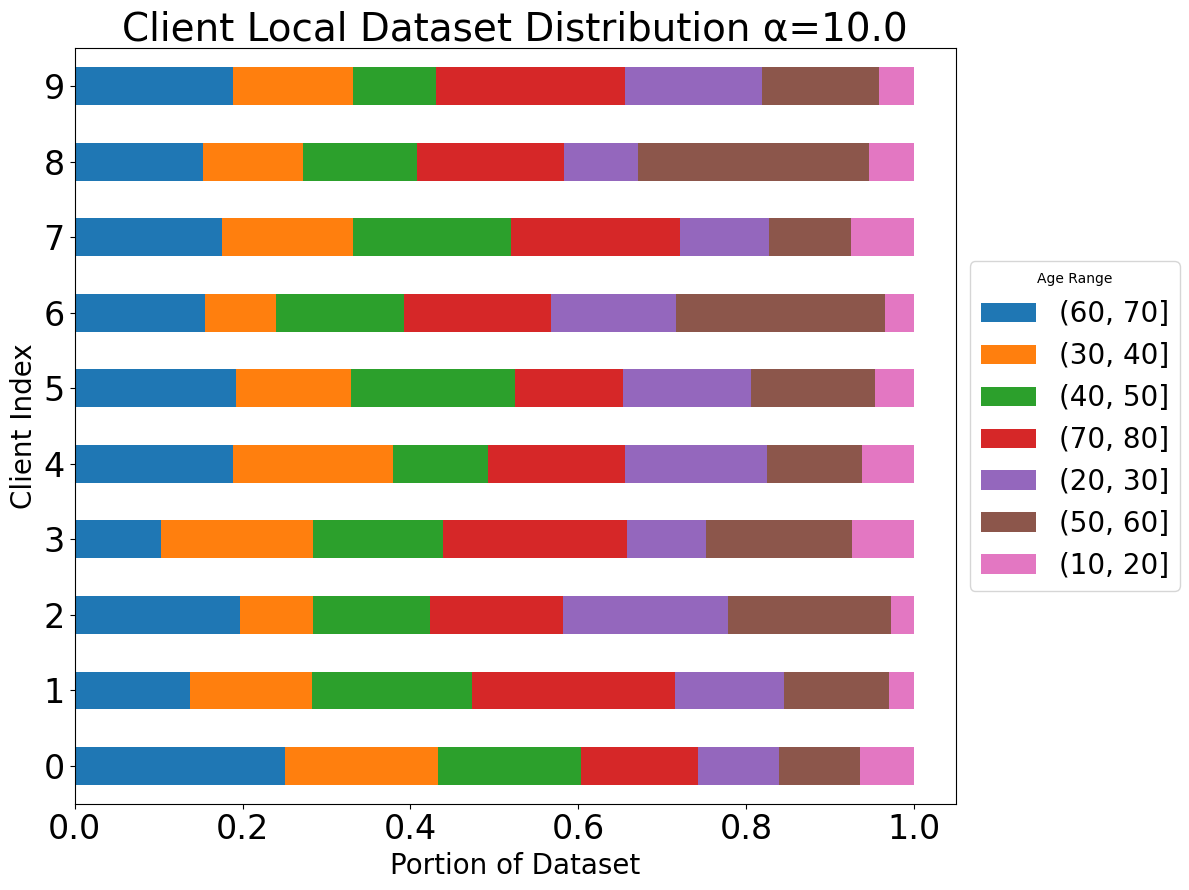

In [5]:
import pickle
bins = [10, 20, 30, 40, 50, 60, 70, 80] 
labels = [str(i) for i in bins]
ages = []
similarity=10.0
num_clients = 10
filename = f"federated/clients{num_clients}-dirichl{similarity}.pkl"

with open(filename, "rb") as f:
    ages = pickle.load(f)
train_counts = pd.DataFrame(ages).T
noniid_arr = [[] for _ in range(num_clients)]
for i in range(num_clients):
    noniid_arr[i] = pd.cut(train_counts[i], bins, labels).value_counts(
        normalize=True
    )
noniid_arr = pd.DataFrame(noniid_arr).T
noniid_arr.columns = [str(i) for i in range(num_clients)]

ax = noniid_arr.T.plot.barh(stacked=True, figsize=(12, 9), fontsize=24)
plt.title(f"Client Local Dataset Distribution α={similarity}", fontsize=28)
#plt.xlabel("Portion of Dataset", fontsize=20)
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), title="Age Range", fontsize=20)

# annotations:
for c in ax.containers:   
    # format the number of decimal places and replace 0 with an empty string
    labels = [f'{w*10:.4f}%' if (w := v.get_width()) > 1 else '' for v in c]
    plt.xlabel("Portion of Dataset", fontsize=20)
    plt.ylabel("Client Index", fontsize=20)
    #ax.bar_label(c, labels=sorted(labels), label_type='edge')
plt.tight_layout()
# dirichl-alpha
plt.savefig(f"{filename}.png", dpi=400)
plt.show()

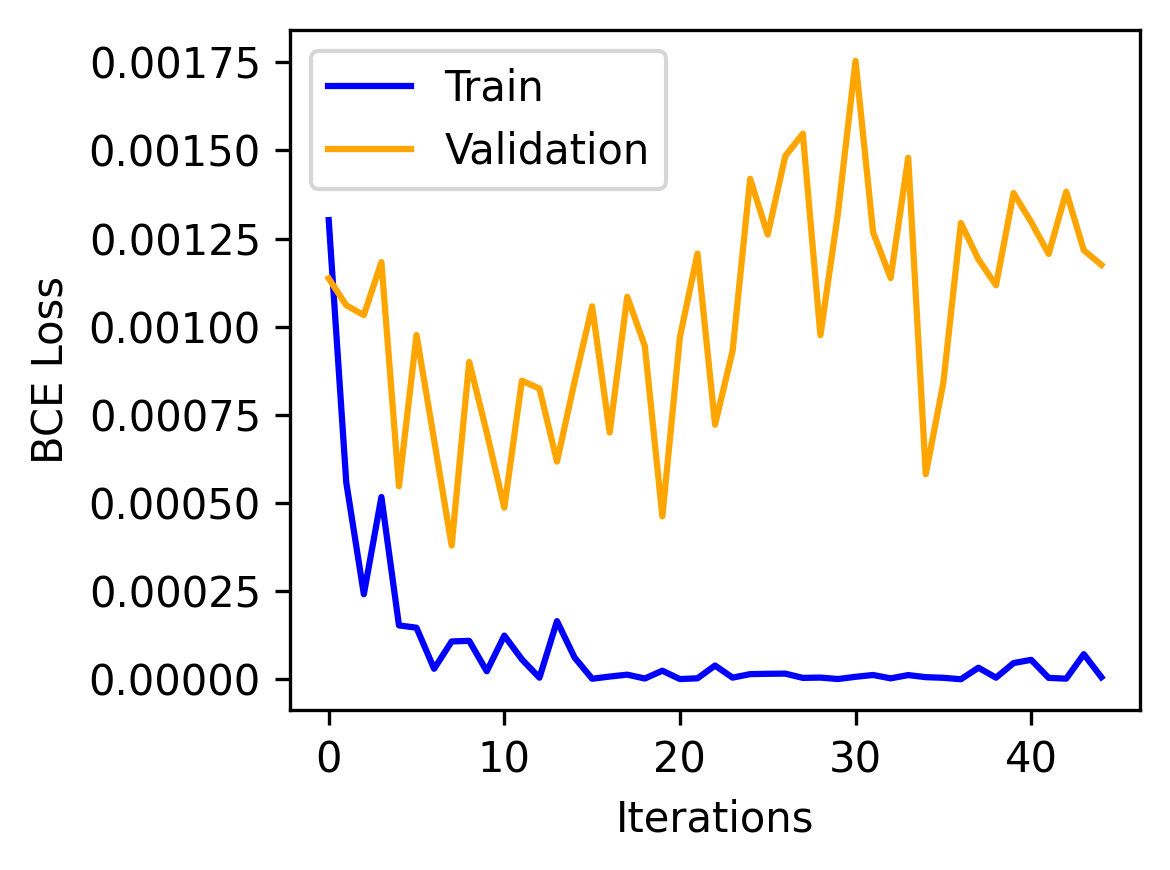

In [6]:
d = pd.read_csv("runs_centralized/1380173-results-partwise-lr1e-05-ep20-exams10.csv")

fig2 = plt.figure(figsize=(4,3), dpi=300)
ax2 = fig2.add_subplot()
#ax2.set_title("Train-Validation Loss Curves - CODE-15% Centralized Training")
ax2.set_xlabel("Iterations")
ax2.set_ylabel("BCE Loss")
ax2.plot(d["epoch"], d["train_loss"], color="blue", label="Train")
ax2.plot(d["epoch"], d["valid_loss"], color="orange", label="Validation")
ax2.legend(loc="best")
fig2.tight_layout()
plt.show()

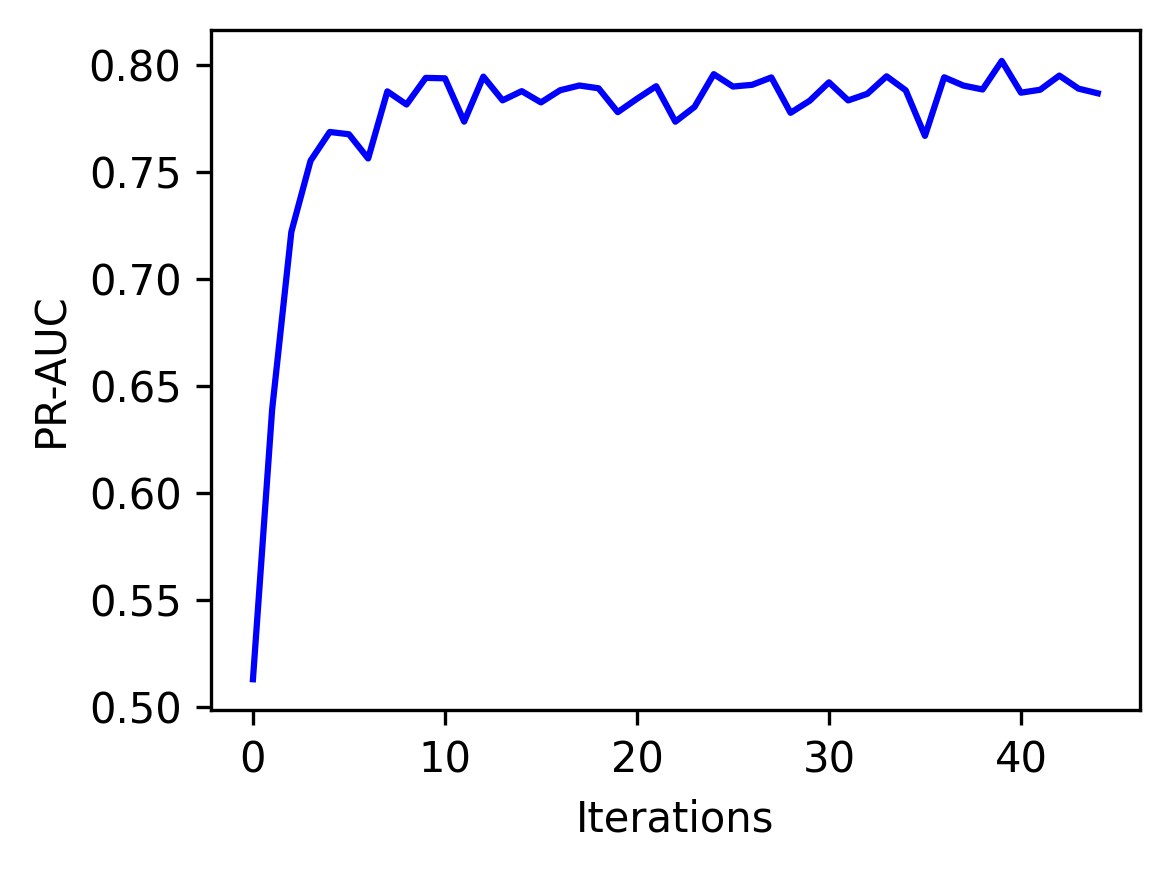

In [7]:
fig2 = plt.figure(figsize=(4,3), dpi=300)
ax2 = fig2.add_subplot()
#ax2.set_title("Avg. Precision - CODE-15% Centralized Training")
ax2.set_xlabel("Iterations")
ax2.set_ylabel("PR-AUC")
ax2.plot(d["epoch"], d["mAP"], color="blue")
#ax2.legend(loc="best")
fig2.tight_layout()
plt.show()

In [ ]:
for i, filepath in enumerate(glob.glob("data/code15-12l/*.hdf5")):
    prefix = filepath.replace("data/code15-12l/", "").replace(".hdf5", "")
    path_to_h5_train, path_to_csv_train = filepath, 'data/code15-12l/exams.csv' # path_to_records = 'data/codesubset/RECORDS.txt'
    
    # load traces
    f = h5py.File(path_to_h5_train, 'r')
    traces = torch.tensor(f['tracings'][()], dtype=torch.float32)[:-1,:,:]
    
    # load labels
    ids_traces = np.array(f['exam_id'])
    df = pd.read_csv(path_to_csv_train)
    df.set_index('exam_id', inplace=True)
    df = df.reindex(ids_traces).dropna(subset=["AF"]) # make sure the order is the same, last entry removed as a nan row is created in the reindexing
    labels = torch.tensor(np.array(df['AF'], dtype=np.float32), dtype=torch.float32, device=device).reshape(-1,1)
    print("\nChunk #", i, ">> number of pos. examples >>", len(df[df['AF']==1]))
    print(">> weight >>", len(df[df['AF']==0])/len(df[df['AF']==1]))
    print(traces.size(), labels.size())
    print("at", i, " >> 50%")

    #### CHECK THE BALANCE
    # Number of female patients 
    print("Number of female patients", len(df[df['is_male'] == 0]))
    females = df[df['is_male'] == 0]
    print("of which positive for AF --", len(females[females['AF']==1]))
    # Number of male patients
    print("Number of male patients", len(df[df['is_male'] == 1]))
    males = df[df['is_male'] == 1]
    print("of which positive for AF --", len(males[males['AF']==1]))
    
    #### SEE HOW IT IS DISTRIBUTED ACROSS GENDERS/AGES
    print("\n----Age Distribution----\n")
    ax = df.plot.hist(column=['age'], bins=10)
    plt.show()

## Training

In [4]:
!pwd

/mimer/NOBACKUP/groups/naiss2024-5-153/Aditya/1-starter-ecg-model


In [5]:
def train_loop(epoch, dataloader, model, optimizer, loss_function, device):
    # model to training mode (important to correctly handle dropout or batchnorm layers)
    model.train()
    # allocation
    total_loss = 0  # accumulated loss
    n_entries = 0   # accumulated number of data points
    # progress bar def
    train_pbar = tqdm(dataloader, desc="Training Epoch {epoch:2d}".format(epoch=epoch), leave=True)
    train_correct = []

    sigmoid = torch.nn.Sigmoid().to(device)
    # training loop
    for traces, diagnoses in train_pbar:
        traces, diagnoses = traces.to(device), diagnoses.to(device)
        
        # data to device (CPU or GPU if available)
        for x,y in dataloader:
            x, y = x.to(device), y.to(device)
            pred = model(x)
            curr_loss = loss_function(pred, y)
            with torch.no_grad():
                train_correct.append((sigmoid(pred).argmax(1) == y).sum().item())

            curr_loss.backward()
            optimizer.step()
            optimizer.zero_grad()

        # Update accumulated values
        total_loss += curr_loss.detach().cpu().numpy()
        n_entries += len(traces)

        # Update progress bar
        train_pbar.set_postfix({'loss': total_loss / n_entries})
    train_pbar.close()
    return total_loss / n_entries

In [6]:
def eval_loop(epoch, dataloader, model, loss_function, device):
    # model to evaluation mode (important to correctly handle dropout or batchnorm layers)
    model.eval()
    # allocation
    total_loss = 0  # accumulated loss
    n_entries = 0   # accumulated number of data points
    avg_precisions = []  # avg precision (pr-auc)
    f1_s = [] # f1-score

    # progress bar def
    eval_pbar = tqdm(dataloader, desc="Evaluation Epoch {epoch:2d}".format(epoch=epoch), leave=True)

    sigmoid = torch.nn.Sigmoid().to(device)
    # evaluation loop
    for traces_cpu, diagnoses_cpu in eval_pbar:
        # data to device (CPU or GPU if available)
        traces, diagnoses = traces_cpu.to(device), diagnoses_cpu.to(device)

        """
        TASK: Insert your code here. This task can be done in 6 lines of code.
        """
        with torch.no_grad():
            for x,y in dataloader:
                xt, yt = x.to(device), y.to(device)
                
                pred = model(xt)
                curr_loss = loss_function(pred, yt)

                if len(np.unique(yt.cpu())) == 2: # if both positive and negative truth values are present, compute the avg. precision
                    avg_precisions.append(average_precision_score(yt.cpu(), sigmoid(pred).cpu()))
                f1_s.append(f1_score(yt.cpu(), sigmoid(pred).cpu().argmax(1), zero_division=0))

            # Update accumulated values
            total_loss += curr_loss.detach().cpu().numpy()
            n_entries += len(traces)
        # Update progress bar
        eval_pbar.set_postfix({'loss': total_loss / n_entries, 'avg_precision': np.mean(avg_precisions), 'avg_f1_score': np.mean(f1_s)})
    eval_pbar.close()
    return total_loss / n_entries, np.mean(avg_precisions), np.mean(f1_s)

In [7]:
######### set seed
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)
batch_size = 128
##########

In [17]:
tloaders

In [ ]:
# =============== Build data loaders ======================================#
tqdm.write("Building data loaders...")

tloaders = []
vloaders = []

for i, filepath in enumerate(glob.glob("data/code15-12l/*.hdf5")):
    prefix = filepath.replace("data/code15-12l/", "").replace(".hdf5", "")
    path_to_h5_train, path_to_csv_train = filepath, 'data/code15-12l/exams.csv' # path_to_records = 'data/codesubset/RECORDS.txt'
    
    # load traces
    f = h5py.File(path_to_h5_train, 'r')
    traces = torch.tensor(f['tracings'][()], dtype=torch.float32)[:-1,:,:]
    
    # load labels
    ids_traces = np.array(f['exam_id'])
    df = pd.read_csv(path_to_csv_train)
    df.set_index('exam_id', inplace=True)
    df = df.reindex(ids_traces).dropna(subset=["AF"]) # make sure the order is the same
    labels = torch.tensor(np.array(df['AF'], dtype=np.float32), dtype=torch.float32, device=device).reshape(-1,1)
    print("\nat", i, ">> number of pos. examples >>", len(df[df['AF']==1]))
    print(">> weight >>", len(df[df['AF']==0])/len(df[df['AF']==1]))
    print(traces.size(), labels.size())
    print("at", i, " >> 50%")
    
    # load dataset
    dataset = TensorDataset(traces, labels)
    len_dataset = len(dataset)
    n_classes = len(torch.unique(labels))

    print("at", i, " >> 75%")
    # split data
    dataset_train, dataset_valid = random_split(dataset, lengths=[0.7,0.3])
    
    # build data loaders
    tloaders.append(DataLoader(dataset_train, batch_size=batch_size, shuffle=True))
    vloaders.append(DataLoader(dataset_valid, batch_size=batch_size, shuffle=False))
    print("at", i, " >> done!")

tqdm.write("Done!\n")

In [ ]:
# =============== Define model ============================================#
tqdm.write("Define model...")
"""
TASK: Replace the baseline model with your model; Insert your code here
"""
model = ResNet1d(input_dim=(12, 4096),
                     blocks_dim=list(zip([64, 128, 196, 256, 320], # net_filter_size
                         [4096, 1024, 256, 64, 16])), # net_sequence_length
                     n_classes=1,
                     kernel_size=17,
                     dropout_rate=0.4) # CustomCNN()
model.to(device=device)
tqdm.write("Done!\n")

learning_rate = 1e-4
weight_decay = 1e-1
num_epochs = 1 # 10
pos_weight = torch.tensor([48], device=device) # mean ratio of neg. samples / pos. samples in all chunks of code15 to tackle class imbalance (only around 2% are positives)

# =============== Define loss function ====================================#
"""
TASK: define the loss; Insert your code here. This can be done in 1 line of code
"""
loss_function = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# =============== Define optimizer ========================================#
tqdm.write("Define optimiser...")
optimizer = torch.optim.Adam(
    model.parameters(), 
    lr=learning_rate, 
    #weight_decay=weight_decay
)
tqdm.write("Done!\n")

# =============== Define lr scheduler =====================================#
# TODO advanced students (non mandatory)
"""OPTIONAL: define a learning rate scheduler; Insert your code here"""
lr_scheduler = torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=1.0, end_factor=0.1, total_iters=10)

# =============== Train model =============================================#
tqdm.write("Training...")
best_loss = np.inf
# allocation
train_loss_all, valid_loss_all = [], []

# MAKE ANOTHER FOR LOOP LOOPING THROUGH ALL DATALOADERS
# loop over epochs
for epoch in trange(1, num_epochs + 1):
    for i in range(len(tloaders)):
        # training loop
        train_loss = train_loop(epoch, tloaders[i], model, optimizer, loss_function, device)
        # validation loop
        valid_loss, avg_precision, avg_roc_auc = eval_loop(epoch, vloaders[i], model, loss_function, device)
    
        # collect losses
        train_loss_all.append(train_loss)
        valid_loss_all.append(valid_loss)
    
        # compute validation metrics for performance evaluation
        """
        TASK: compute validation metrics (e.g. AUROC); Insert your code here
        This can be done e.g. in 5 lines of code
        """
        # y_pred, y_true <-- DO SOMETHING FOR THESE!!
    
        # save best model: 
        # here we save the model only for the lowest validation loss
        if valid_loss < best_loss:
            # Save model parameters
            torch.save({'model': model.state_dict()}, 'resnet-model-code15.pth')
            # Update best validation loss
            best_loss = valid_loss
            # statement
            model_save_state = "Best model -> saved"
        else:
            model_save_state = ""
    
        # Update learning rate with lr-scheduler
        if lr_scheduler:
            print("scheduler updated lr ...")
            lr_scheduler.step()

    # Print message
    tqdm.write('Epoch {epoch:2d}: \t'
                'Train Loss {train_loss:.6f} \t'
                'Valid Loss {valid_loss:.6f} \t'
                '{model_save}'
                .format(epoch=epoch,
                        train_loss=train_loss,
                        valid_loss=valid_loss,
                        model_save=model_save_state))

"""TASK: Here it can make sense to plot your learning curve; Insert your code here"""
plt.plot(np.arange(len(tloaders)), train_loss_all)
plt.plot(np.arange(len(tloaders)), valid_loss_all)
plt.show()

In [23]:
# average precision: 0.831